In [1]:
import copy
import warnings

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

warnings.filterwarnings("ignore")

# Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Hyper Parameters

In [3]:
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50          # early stopping이 있으므로 넉넉하게 설정
PATIENCE = 5             # val loss가 PATIENCE 에폭 동안 개선되지 않으면 조기 종료
VAL_SIZE = 10_000        # train(60k)에서 검증용으로 떼어낼 개수

# Data Definition

In [4]:
transform = transforms.ToTensor()

In [5]:
# MNIST train(60k) / test(10k)
# train은 아래에서 다시 train/validation으로 분할함
train_full = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=transform,
)

test_set = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=False,
    transform=transform,
)

In [6]:
# 재현성을 위해 generator 고정
generator = torch.Generator().manual_seed(42)

train_size = len(train_full) - VAL_SIZE  # 50,000
train_set, val_set = torch.utils.data.random_split(
    train_full, [train_size, VAL_SIZE], generator=generator
)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Train: 50000, Val: 10000, Test: 10000


In [7]:
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Architecture

In [8]:
class Autoencoder(nn.Module):
    """
    Encoder : (784) -> (128) -> (32)
    Decoder : (32) -> (128) -> (784)
    Sigmoid : 픽셀값을 [0,1]로 만들기 위해 사용
    """

    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(), nn.Linear(128, 32), nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 128), nn.ReLU(), nn.Linear(128, 28 * 28), nn.Sigmoid()
        )

    def forward(self, x):
        # x: [batch_size, 784]
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Training

In [9]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [10]:
@torch.no_grad()
def evaluate_loss(model, loader):
    """loader 전체에 대한 평균 재구성 손실(MSE). 라벨은 사용하지 않는다."""
    model.eval()
    total_loss = 0.0
    for images, _ in loader:
        images = images.view(images.size(0), -1).to(device)
        outputs = model(images)
        total_loss += criterion(outputs, images).item()
    return total_loss / len(loader)

In [11]:
best_val_loss = float("inf")
best_model_state = None
epochs_no_improve = 0
history = {"train": [], "val": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        # MNIST 이미지는 [batch_size, 1, 28, 28] 형태
        # 오토인코더 입력을 위해 (batch_size, 784) 형태로 펼쳐줌
        images = images.view(images.size(0), -1).to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss = evaluate_loss(model, val_loader)
    history["train"].append(train_loss)
    history["val"].append(val_loss)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}], "
        f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
    )

    # Early stopping: val loss 기준으로 best 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch+1} "
                f"(best val loss: {best_val_loss:.4f})"
            )
            break

# 학습 종료 후 best(검증손실 최소) 가중치로 복원
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model (val loss: {best_val_loss:.4f})")

Epoch [1/50], Train Loss: 0.0734, Val Loss: 0.0447
Epoch [2/50], Train Loss: 0.0365, Val Loss: 0.0301
Epoch [3/50], Train Loss: 0.0267, Val Loss: 0.0243
Epoch [4/50], Train Loss: 0.0222, Val Loss: 0.0207
Epoch [5/50], Train Loss: 0.0195, Val Loss: 0.0190
Epoch [6/50], Train Loss: 0.0181, Val Loss: 0.0178
Epoch [7/50], Train Loss: 0.0172, Val Loss: 0.0169
Epoch [8/50], Train Loss: 0.0163, Val Loss: 0.0161
Epoch [9/50], Train Loss: 0.0157, Val Loss: 0.0155
Epoch [10/50], Train Loss: 0.0151, Val Loss: 0.0150
Epoch [11/50], Train Loss: 0.0147, Val Loss: 0.0147
Epoch [12/50], Train Loss: 0.0143, Val Loss: 0.0143
Epoch [13/50], Train Loss: 0.0140, Val Loss: 0.0142
Epoch [14/50], Train Loss: 0.0138, Val Loss: 0.0139
Epoch [15/50], Train Loss: 0.0135, Val Loss: 0.0136
Epoch [16/50], Train Loss: 0.0133, Val Loss: 0.0135
Epoch [17/50], Train Loss: 0.0131, Val Loss: 0.0132
Epoch [18/50], Train Loss: 0.0129, Val Loss: 0.0130
Epoch [19/50], Train Loss: 0.0127, Val Loss: 0.0128
Epoch [20/50], Train 

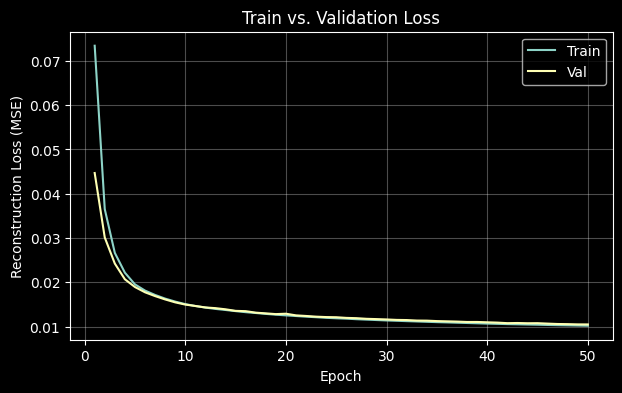

In [12]:
plt.figure(figsize=(7, 4))

plt.plot(range(1, len(history["train"]) + 1), history["train"], label="Train")
plt.plot(range(1, len(history["val"]) + 1), history["val"], label="Val")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("Train vs. Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluation

In [13]:
test_loss = evaluate_loss(model, test_loader)
print(f"Test Reconstruction Loss (MSE): {test_loss:.4f}")

Test Reconstruction Loss (MSE): 0.0101


In [14]:
model.eval()

test_iter = iter(test_loader)
test_images, _ = next(test_iter)

## Results

In [15]:
# 샘플 8개만 확인
sample_images = test_images[:8].to(device)  # shape: [8, 1, 28, 28]
sample_images_flat = sample_images.view(8, -1)  # shape: [8, 784]

In [16]:
# 모델 복원
with torch.no_grad():
    reconstructed = model(sample_images_flat)  # shape: [8, 784]

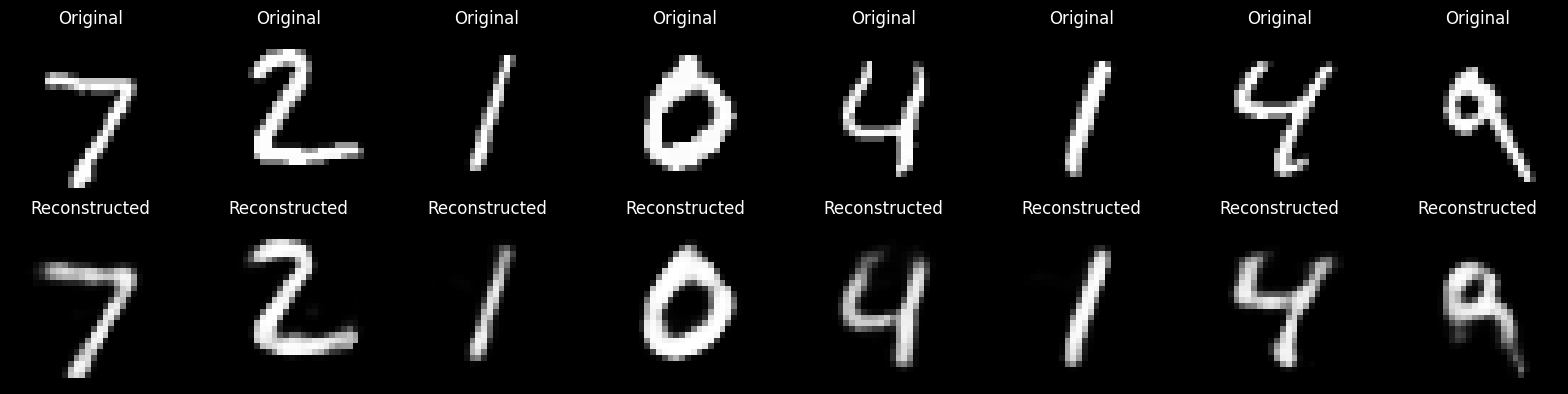

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(16, 4))

for i in range(8):
    # 원본 이미지 (이미 [0,1] 범위이므로 그대로 사용)
    axes[0, i].imshow(
        sample_images[i].view(28, 28).cpu().numpy(), cmap="gray", vmin=0, vmax=1
    )
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    # 복원된 이미지 ([0,1] 범위)
    axes[1, i].imshow(
        reconstructed[i].view(28, 28).cpu().numpy(), cmap="gray", vmin=0, vmax=1
    )
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

---
End of Documents